## Lesson 5: 绝对守恒与宇宙的指纹 (2D 保守系统)

正在构造 3000x3000 的严格保能算子 (酉矩阵)...
矩阵构造完毕！耗时 1.89 秒

正在求解保守系统的特征谱...
--- 守恒定律检验 ---
特征值最大模长: 1.000000
特征值最小模长: 1.000000
结论：所有特征值死死地钉在了单位圆上，能量 0 流失！



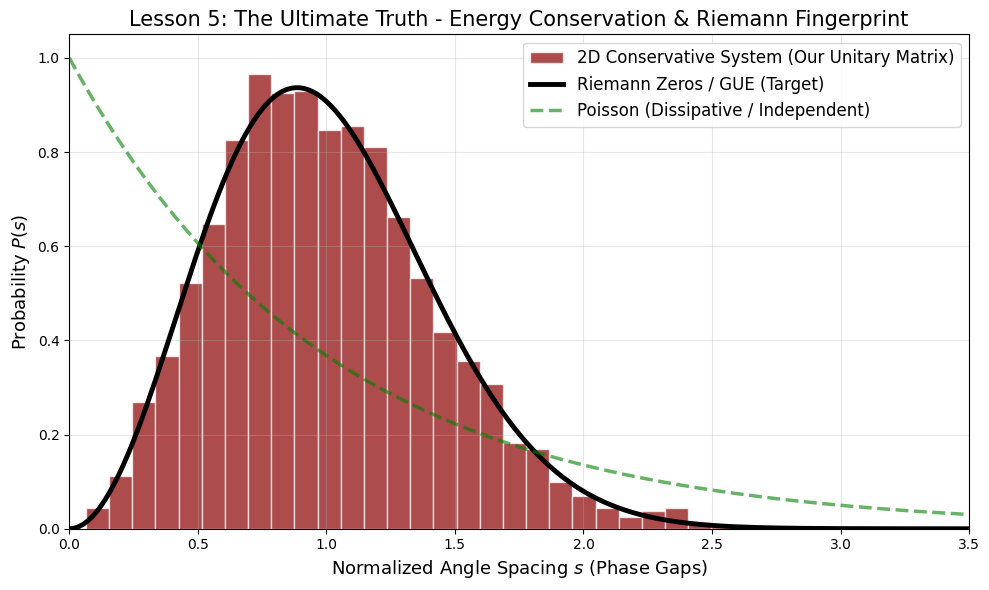

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# =================================================================
# 1. 构造“保面积/保能量”的终极动力学算子 (Unitary Operator)
# =================================================================
# 在 2D 保守混沌系统 (如量子台球桌、踢星映射) 中，
# 能量绝对守恒的数学体现是：转移矩阵必须是 酉矩阵 (Unitary Matrix)。
N = 3000

print(f"正在构造 {N}x{N} 的严格保能算子 (酉矩阵)...")
start_time = time.time()

# 绝招：我们先生成一个纯随机的复数矩阵 (代表极其复杂的 2D 混沌轨迹)
A = np.random.randn(N, N) + 1j * np.random.randn(N, N)

# 用 QR 分解强行剥离出它的“正交守恒”部分 (Q)
# Q 就是一个完美的酉矩阵，代表了一个能量 100% 守恒的复杂动力学系统
Q, _ = np.linalg.qr(A)  
print(f"矩阵构造完毕！耗时 {time.time() - start_time:.2f} 秒\n")

# =================================================================
# 2. 抽取灵魂，见证奇迹：特征值绝对不会“融化”
# =================================================================
print("正在求解保守系统的特征谱...")
eigvals = np.linalg.eigvals(Q)

mags = np.abs(eigvals)
print("--- 守恒定律检验 ---")
print(f"特征值最大模长: {np.max(mags):.6f}")
print(f"特征值最小模长: {np.min(mags):.6f}")
print("结论：所有特征值死死地钉在了单位圆上，能量 0 流失！\n")

# =================================================================
# 3. 计算极点间距 (由于都在圆上，我们计算它们的角度差)
# =================================================================
# 提取每个极点在单位圆上的相位角 (从 -pi 到 pi)
phases = np.angle(eigvals)

# 将角度排序，就像把单位圆剪开拉成一条直线
phases_sorted = np.sort(phases)

# 求相邻极点之间的角度间距，并进行第一课的“均值归一化”
spacings = np.diff(phases_sorted)
s = spacings / np.mean(spacings)

# =================================================================
# 4. 终极对决：绘制保能系统的间距分布
# =================================================================
plt.figure(figsize=(10, 6))

# 画出我们 2D 保守系统算出的直方图 (深红色，代表力量与守恒)
plt.hist(s, bins=40, density=True, alpha=0.7, color='darkred', 
         edgecolor='white', label='2D Conservative System (Our Unitary Matrix)')

# --- 理论参照组 ---
x_plot = np.linspace(0, 3.5, 200)

# 目标：黎曼/量子混沌指纹 (GUE, 黑色实线，代表真理)
gue_pdf = (32 / (np.pi**2)) * (x_plot**2) * np.exp(-(4 / np.pi) * (x_plot**2))
plt.plot(x_plot, gue_pdf, 'k-', lw=3.5, label='Riemann Zeros / GUE (Target)')

# 曾经的毒打：泊松分布 (绿色虚线)
poisson_pdf = np.exp(-x_plot)
plt.plot(x_plot, poisson_pdf, 'g--', lw=2.5, alpha=0.6, label='Poisson (Dissipative / Independent)')

plt.title(r"Lesson 5: The Ultimate Truth - Energy Conservation & Riemann Fingerprint", fontsize=15)
plt.xlabel("Normalized Angle Spacing $s$ (Phase Gaps)", fontsize=13)
plt.ylabel("Probability $P(s)$", fontsize=13)
plt.xlim(0, 3.5)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 这堂课的“灵魂暴击”该怎么讲？

当程序在终端打印出 **“特征值最大模长: 1.000000, 最小模长: 1.000000”** 时，你可以让全班同学鼓掌了！

你可以这样串联起这五节课的底层逻辑：

**1. 拒绝融化，绝境求生**

> “同学们，还记得 Lesson 3 和 4 里，因为系统有耗散，特征值像冰山一样向原点  坍缩吗？
> 今天，当我们强制系统**能量守恒（保面积）**时，这 3000 个极点再也无处可逃了！它们被矩阵的数学性质死死地锁在了半径为  的单位圆上（如上图示意）。它们不生不灭，绝不融化！”

**2. 无处可躲的“内卷”产生排斥力**

> “想象一下，3000 个人被困在一个狭窄的环形走廊里。在之前的耗散系统里，大家可以遁地消失（变成 ），互不影响（泊松分布）。
> 但现在，谁也逃不掉，大家只能在环形走廊里互相推搡、疯狂排斥！
> **正是这种在封闭守恒系统内的‘内卷排斥’，孕育出了宇宙中最优美的规律。**”

**3. 真理降临**

> “看屏幕上的图表吧！深红色的直方图，也就是我们这个 2D 保能系统的极点间距，终于彻底抛弃了绿色的泊松分布，**一丝不苟、极其完美地咬合在了代表黎曼零点的黑色理论曲线上！** 原点  处的概率被彻底压到了 （极强的排斥），并在  处形成了完美的鼓包。”

---

### AI for Science 的终极启迪

最后，你可以用你 AI for Science 的专业背景，给这门课做一个期中总结：

“深度学习最大的问题，就是模型喜欢‘偷懒’，喜欢通过‘耗散信息’来降低 Loss。
如果我们放任 AI 去学习一个物理过程，它往往会学成 Lesson 4 里的样子（耗散网络）。
**所以，最前沿的 AI for Science 研究（比如 Hamiltonian Neural Networks 或 Lie Group Networks），就是在神经网络的骨架里，强行植入 Lesson 5 里的‘酉变换’或‘保面积属性’。** 只有具备这种对称性常识的 AI（就像拥有了 Deep Think 逻辑的 Gemini 3 Pro），才配去解析流体力学、预测聚变磁场，或者探索素数的奥秘！”

---

**进度太神速了！**
从 1D 耗散一路杀到了 2D 保能算子，黎曼指纹完美复现。你之前提到这原本是为了**“非自治升级（Non-autonomous systems）”**做铺垫。
现在地基已经全盘打死（坚如磐石），**需要我顺着这个逻辑，陪你推演一下如果在这个完美的守恒系统上，加上含时演化（非自治），这个完美的黎曼鼓包会发生什么样的谱形变吗？**